# Shapflow with Data-Driven Graph Construction

Adapting shapflow.flow to work with discovered causal structures by using **empirical conditional distributions** instead of theoretical functions.

**Key Insight from Tutorial:**
- Source nodes (no parents): Just names, no functions needed
- Intermediate nodes (with parents): Need functions - we'll use data-driven sampling
- Target node (Y): Use the ML model

This bridges the gap between the tutorial (known mechanisms) and our case (discovered structure only).

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import sys

# Add shapflow to path if needed
shapflow_path = Path.cwd() / 'shapflow'  # Adjust if shapflow is elsewhere
if shapflow_path.exists() and str(shapflow_path) not in sys.path:
    sys.path.insert(0, str(shapflow_path))

from shapflow.flow import Node, Graph, GraphExplainer
from predictive_models.predictive_models import LGBMRegressor

print("✅ Imports successful")

✅ Imports successful


## 1. Load Data and Model

In [2]:
# Dataset configuration
dataset_name = "mixed_no_conf_f50_s1000_p50"

# Load data
train_data = pd.read_parquet(f"data/processed/{dataset_name}_train.parquet")
test_data = pd.read_parquet(f"data/processed/{dataset_name}_test.parquet")

X_train = train_data.drop('Y', axis=1)
y_train = train_data['Y']
X_test = test_data.drop('Y', axis=1)
y_test = test_data['Y']

# Load model
model = LGBMRegressor.load(f"models/{dataset_name}_lgbm")

print(f"Data: {X_train.shape}, Model features: {len(model.selected_features)}")

LightGBM model loaded from models/mixed_no_conf_f50_s1000_p50_lgbm.pkl
Data: (800, 50), Model features: 50


In [3]:
train_data["Y"].describe()

count    800.000000
mean       0.014874
std        1.100613
min       -7.638759
25%       -0.475177
50%       -0.034988
75%        0.417622
max        7.271624
Name: Y, dtype: float64

In [4]:
# Load causal structure
# adjacency_matrix = np.load(f"data/causal/{dataset_name}_pc_train_adjacency.npy")
import json
results_path = f"data/causal/{dataset_name}_pc_results.json"
with open(results_path, 'r') as f:
    results_json = json.load(f)
adjacency_matrix = np.array(results_json['adjacency_matrix'])
n_features = adjacency_matrix.shape[0]

print(f"Causal structure: {adjacency_matrix.shape}")
print(f"Edges: {np.sum(adjacency_matrix != 0)}")

Causal structure: (51, 51)
Edges: 80


## 2. Build Data-Driven Conditional Samplers

Since we don't know the true causal functions, we'll create empirical samplers that learn from data.

In [5]:
def adjacency_to_graph(adjacency_matrix, feature_names, train_data):
    """
    Convert adjacency matrix to shapflow Graph object.
    
    Parameters:
    -----------
    adjacency_matrix : np.ndarray
        Adjacency matrix where adjacency[i, j] != 0 means feature i is a parent of feature j
    feature_names : list
        List of feature names (e.g., ['X1', 'X2', ..., 'Y'])
    train_data : pd.DataFrame
        Training data to fit the causal functions
    
    Returns:
    --------
    Graph : shapflow.flow.Graph object with learned causal functions
    """
    n_features = len(feature_names)
    
    # Step 1: Create all nodes first (without parent relationships)
    nodes_dict = {}
    for i, name in enumerate(feature_names):
        # Determine if this is the target node
        is_target = (name == 'Y')
        
        # Create node (args will be added later)
        node = Node(
            name=name,
            f=None,
            args=[],
            is_target_node=is_target,
            is_noise_node=False,
            is_dummy_node=False,
            is_categorical=False
        )
        nodes_dict[name] = node
    
    # Step 2: Add parent relationships based on adjacency matrix
    for j, child_name in enumerate(feature_names):
        child_node = nodes_dict[child_name]
        
        # Find parents: where adjacency[i, j] != 0 means i is parent of j
        parent_indices = np.where(adjacency_matrix[:, j] != 0)[0]
        
        # Add each parent to the child's args
        for parent_idx in parent_indices:
            parent_name = feature_names[parent_idx]
            parent_node = nodes_dict[parent_name]
            child_node.args.append(parent_node)
            # Also add child to parent's children list
            if child_node not in parent_node.children:
                parent_node.children.append(child_node)
    
    # Step 3: Create Graph object
    graph = Graph(nodes=list(nodes_dict.values()))
    
    # Step 4: Fit missing links (learn causal functions from data)
    print("Learning causal functions from training data...")
    graph.fit_missing_links(train_data, method='xgboost')
    
    return graph

print("✅ Helper function created")

✅ Helper function created


## Step 1: Create Graph from Adjacency Matrix

In [6]:
# Get feature names from train_data
feature_names = list(train_data.columns)
print(f"Features: {len(feature_names)} total")
print(f"Feature names: {feature_names[:5]}... Y")

# Create the Graph from adjacency matrix
# This will create nodes and learn causal functions
graph = adjacency_to_graph(adjacency_matrix, feature_names, train_data)

print(f"\n✅ Graph created with {len(graph.nodes)} nodes")
print(f"Source nodes (no parents): {sum(1 for n in graph.nodes if len(n.args) == 0)}")
print(f"Target node: {[n.name for n in graph.nodes if n.is_target_node]}")

Features: 51 total
Feature names: ['X0', 'X1', 'X2', 'X3', 'X4']... Y
Learning causal functions from training data...


learning dependency for X4:   0%|          | 0/49 [00:00<?, ?it/s]

[0]	test-rmse:0.99652
[100]	test-rmse:0.89082
[200]	test-rmse:0.80596
[300]	test-rmse:0.73929
[400]	test-rmse:0.68703
[499]	test-rmse:0.64842


learning dependency for X22:   2%|▏         | 1/49 [00:00<00:27,  1.75it/s]

[0]	test-rmse:0.95009
[100]	test-rmse:0.93433
[200]	test-rmse:0.92309
[300]	test-rmse:0.91710
[400]	test-rmse:0.91388
[499]	test-rmse:0.91187


...

[0]	test-rmse:1.03219
[100]	test-rmse:0.97186
[200]	test-rmse:0.92845
[300]	test-rmse:0.89757
[400]	test-rmse:0.87658
[499]	test-rmse:0.86276


learning dependency for X15:  98%|█████████▊| 48/49 [00:27<00:00,  1.78it/s]

[0]	test-rmse:1.18795
[100]	test-rmse:1.06561
[200]	test-rmse:0.97195
[300]	test-rmse:0.90138
[400]	test-rmse:0.84924
[499]	test-rmse:0.81136


learning dependency for X15: 100%|██████████| 49/49 [00:27<00:00,  1.78it/s]


✅ Graph created with 51 nodes
Source nodes (no parents): 2
Target node: ['Y']


In [7]:
[node for node in graph.nodes if node.is_target_node]

[Y]

## Step 3: Create GraphExplainer

Now we'll create the GraphExplainer with:
- Background: 100 random samples from training data
- Foreground: First 2 test instances

In [8]:
# Prepare background data: 100 random samples from training data (including Y)
np.random.seed(42)
bg_indices = np.random.choice(len(train_data), size=100, replace=False)
background_data = train_data.iloc[bg_indices]

# Prepare foreground data: First 2 test instances (including Y)
TEST_INSTANCES_RATIO = 0.5 # Use 50% of test data for foreground
RANDOM_STATE = 42   
foreground_data = test_data.sample(n=int(len(test_data) * TEST_INSTANCES_RATIO), random_state=RANDOM_STATE)

print(f"Background data: {background_data.shape}")
print(f"Foreground data: {foreground_data.shape}")
print(f"\nForeground instances:")
print(foreground_data[['Y']].head())

# Create GraphExplainer
explainer = GraphExplainer(
    graph=graph,
    bg=background_data,
    nruns=100,  # Number of Monte Carlo samples
    silent=False
)

print(f"\n✅ GraphExplainer created successfully!")

Background data: (100, 51)
Foreground data: (100, 51)

Foreground instances:
            Y
436 -0.233546
899 -0.397322
346 -0.196530
60   0.270463
867 -0.577449

✅ GraphExplainer created successfully!


In [9]:
test_data.shape

(200, 51)

## Test: Compute SHAP Values

Let's compute the Shapley Flow values for our test instances:

In [10]:
# Compute SHAP values using the GraphExplainer
# This uses the Shapley Flow algorithm with the learned causal graph
cf = explainer.shap_values(
    X=foreground_data,
    method='bruteforce_sampling',  # Monte Carlo sampling method
    # method_type='distributed'  # Use distributed edge axioms
)

print("\n✅ Shapley Flow computation complete!")
print(f"Edge credits computed: {len(cf.edge_credit)} parent nodes")

bruteforce sampling: 100%|██████████| 100/100 [01:22<00:00,  1.21it/s]


✅ Shapley Flow computation complete!
Edge credits computed: 33 parent nodes


In [11]:
def get_node_attributions(edge_credit):
        """
        Aggregate edge attributions to get node-level importance

        Returns: 
        --------
        node_attr :
            Node importance scores (sum of outgoing edge attributions)
        """

        node_attr = {}
        for node1, d in edge_credit.items():
            if "noise" not in node1.name:
                for node2, val in d.items():
                    node_attr[node1.name] = node_attr.get(node1, 0.0) + val
        return node_attr

In [12]:
def convert_node_attributions_to_array(node_attributions, feature_names):
    """
    Convert node attributions dictionary to standard SHAP format array.
    
    Parameters:
    -----------
    node_attributions : dict
        Dictionary from get_node_attributions with format {feature_name: array_of_shap_values}
        where each array has shape (n_instances,)
    feature_names : list
        List of all feature names in the correct order (e.g., from X.columns)
        Should NOT include 'Y' (target)
    
    Returns:
    --------
    shap_array : np.ndarray
        Array of shape (n_instances, n_features) with SHAP values
        Features not in node_attributions get value 0
    """
    # Remove 'Y' from feature names if present
    feature_names = [f for f in feature_names if f != 'Y']
    
    # Get number of instances from any feature in the dictionary
    if len(node_attributions) > 0:
        first_feature = list(node_attributions.keys())[0]
        n_instances = len(node_attributions[first_feature])
    else:
        raise ValueError("node_attributions is empty")
    
    n_features = len(feature_names)
    
    # Initialize array with zeros
    shap_array = np.zeros((n_instances, n_features))
    
    # Fill in SHAP values for features that have them
    for i, feature_name in enumerate(feature_names):
        if feature_name in node_attributions:
            shap_array[:, i] = node_attributions[feature_name]
        # else: remains 0
    
    return shap_array

print("✅ Conversion helper function created")

✅ Conversion helper function created


### Convert to Standard SHAP Array Format (100 × 50)

In [13]:
# Get node attributions (17 features x 100 instances dictionary)
shap_values_dict = get_node_attributions(cf.edge_credit)

print(f"Dictionary format: {len(shap_values_dict)} features")
print(f"Sample feature shapes:")
for i, (feature, values) in enumerate(list(shap_values_dict.items())[:3]):
    print(f"  {feature}: {values.shape}")

# Convert to standard array format (100 instances x 50 features)
X_feature_names = [col for col in feature_names if col != 'Y']
shap_values_array = convert_node_attributions_to_array(shap_values_dict, X_feature_names)

print(f"\n✅ Converted to array format: {shap_values_array.shape}")
print(f"   Shape: (n_instances={shap_values_array.shape[0]}, n_features={shap_values_array.shape[1]})")
print(f"\nFeatures with non-zero SHAP values: {np.sum(np.any(shap_values_array != 0, axis=0))}")
print(f"Features with zero SHAP values: {np.sum(np.all(shap_values_array == 0, axis=0))}")

Dictionary format: 17 features
Sample feature shapes:
  X30: (100,)
  X48: (100,)
  X18: (100,)

✅ Converted to array format: (100, 50)
   Shape: (n_instances=100, n_features=50)

Features with non-zero SHAP values: 17
Features with zero SHAP values: 33


In [14]:
shap_values_array

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 50))

In [28]:

base_path = f"data/explainability/{dataset_name}/lgbm"
pc_flow_path = f"{base_path}/pc/flow_real"
np.save(f"{pc_flow_path}/shapley_values.npy", shap_values_array)

In [15]:
# Verify the conversion: Check that feature order matches
print("Feature Order Verification:")
print("=" * 70)
print(f"Total features in X: {len(X_feature_names)}")
print(f"First 5 features: {X_feature_names[:5]}")
print(f"Last 5 features: {X_feature_names[-5:]}")

# Check a specific feature's values match
test_feature = list(shap_values_dict.keys())[0]  # Take first feature from dict
feature_idx = X_feature_names.index(test_feature)

print(f"\nVerification for feature '{test_feature}':")
print(f"  Position in array: column {feature_idx}")
print(f"  Dict values (first 5 instances): {shap_values_dict[test_feature][:5]}")
print(f"  Array values (first 5 instances): {shap_values_array[:5, feature_idx]}")
print(f"  Match: {np.allclose(shap_values_dict[test_feature], shap_values_array[:, feature_idx])}")

# Check that features not in DAG have zero values
non_dag_features = [f for f in X_feature_names if f not in shap_values_dict]
print(f"\nFeatures NOT in DAG (should be all zeros): {len(non_dag_features)}")
if non_dag_features:
    print(f"  Examples: {non_dag_features[:5]}")
    # Verify they're zeros
    test_non_dag = non_dag_features[0]
    test_idx = X_feature_names.index(test_non_dag)
    print(f"  '{test_non_dag}' values: {shap_values_array[:5, test_idx]}")
    print(f"  All zeros: {np.all(shap_values_array[:, test_idx] == 0)}")

Feature Order Verification:
Total features in X: 50
First 5 features: ['X0', 'X1', 'X2', 'X3', 'X4']
Last 5 features: ['X45', 'X46', 'X47', 'X48', 'X49']

Verification for feature 'X30':
  Position in array: column 30
  Dict values (first 5 instances): [-0.04067017  0.02388293  0.00651405 -0.03495873  0.0066981 ]
  Array values (first 5 instances): [-0.04067017  0.02388293  0.00651405 -0.03495873  0.0066981 ]
  Match: True

Features NOT in DAG (should be all zeros): 33
  Examples: ['X0', 'X1', 'X3', 'X6', 'X7']
  'X0' values: [0. 0. 0. 0. 0.]
  All zeros: True


### Summary: SHAP Values Format

**Original Dictionary Format (from `get_node_attributions`):**
- Structure: `{feature_name: array_of_100_shap_values}`
- Only 17 features (those in the DAG)
- Example: `{'X1': [shap_inst0, shap_inst1, ...], 'X5': [...], ...}`

**Converted Array Format (standard SHAP format):**
- Structure: `np.ndarray` of shape `(100, 50)`
- **Rows**: 100 instances (each row = one instance)
- **Columns**: 50 features (in same order as original X data)
- Features NOT in DAG have SHAP value = 0
- **Compatible** with all standard SHAP visualization and analysis tools!

**Usage:**
```python
# Get SHAP values for instance i, feature j
shap_value = shap_values_array[i, j]

# Get all SHAP values for instance i
instance_values = shap_values_array[i, :]

# Get all SHAP values for feature j across all instances
feature_values = shap_values_array[:, j]
```

In [ ]:
# pc_flow_path = f"{base_path}/pc/flow/shapley_values.npy"

## Comparison: GraphExplainer vs ShapleyFlowWrapper

Let's compare SHAP values from two approaches:
1. **GraphExplainer** (original shapflow.flow) - stored in `shap_values_array`
2. **ShapleyFlowWrapper** (our implementation) - stored on disk

In [29]:
# Load ShapleyFlowWrapper results from disk
base_path = f"data/explainability/{dataset_name}/lgbm"
pc_flow_wrapper_path = f"{base_path}/pc/flow/shapley_values.npy"

wrapper_shap_values = np.load(pc_flow_wrapper_path)

print("=" * 70)
print("LOADED SHAP VALUES")
print("=" * 70)
print(f"\n📊 GraphExplainer (original shapflow.flow):")
print(f"   Shape: {shap_values_array.shape}")
print(f"   Method: GraphExplainer with learned XGBoost functions")

print(f"\n📊 ShapleyFlowWrapper (our implementation):")
print(f"   Shape: {wrapper_shap_values.shape}")
print(f"   Method: Path sampling with conditional expectations")

# Verify shapes match
if shap_values_array.shape == wrapper_shap_values.shape:
    print(f"\n✅ Shapes match: {shap_values_array.shape}")
else:
    print(f"\n⚠️  Shape mismatch!")
    print(f"   GraphExplainer: {shap_values_array.shape}")
    print(f"   Wrapper: {wrapper_shap_values.shape}")

LOADED SHAP VALUES

📊 GraphExplainer (original shapflow.flow):
   Shape: (100, 50)
   Method: GraphExplainer with learned XGBoost functions

📊 ShapleyFlowWrapper (our implementation):
   Shape: (100, 50)
   Method: Path sampling with conditional expectations

✅ Shapes match: (100, 50)


### Feature Coverage Comparison

Which features get non-zero SHAP values in each approach?

In [30]:
# Identify features with non-zero SHAP values
# GraphExplainer approach
graphexplainer_nonzero_mask = np.any(shap_values_array != 0, axis=0)
graphexplainer_nonzero_features = [X_feature_names[i] for i, has_value in enumerate(graphexplainer_nonzero_mask) if has_value]

# ShapleyFlowWrapper approach
wrapper_nonzero_mask = np.any(wrapper_shap_values != 0, axis=0)
wrapper_nonzero_features = [X_feature_names[i] for i, has_value in enumerate(wrapper_nonzero_mask) if has_value]

print("=" * 70)
print("FEATURE COVERAGE COMPARISON")
print("=" * 70)

print(f"\n📊 GraphExplainer (original flow):")
print(f"   Features with non-zero SHAP: {len(graphexplainer_nonzero_features)}/{len(X_feature_names)}")
print(f"   Features: {sorted(graphexplainer_nonzero_features)}")

print(f"\n📊 ShapleyFlowWrapper (our implementation):")
print(f"   Features with non-zero SHAP: {len(wrapper_nonzero_features)}/{len(X_feature_names)}")
print(f"   Features: {sorted(wrapper_nonzero_features)}")

# Set comparison
graphexplainer_set = set(graphexplainer_nonzero_features)
wrapper_set = set(wrapper_nonzero_features)

common_features = graphexplainer_set & wrapper_set
only_graphexplainer = graphexplainer_set - wrapper_set
only_wrapper = wrapper_set - graphexplainer_set

print(f"\n🔍 Comparison:")
print(f"   Features in BOTH approaches: {len(common_features)}")
print(f"   Only in GraphExplainer: {len(only_graphexplainer)}")
print(f"   Only in Wrapper: {len(only_wrapper)}")

if len(common_features) > 0:
    print(f"\n   ✅ Common features ({len(common_features)}): {sorted(list(common_features))}")
if len(only_graphexplainer) > 0:
    print(f"\n   ⚠️  Only GraphExplainer ({len(only_graphexplainer)}): {sorted(list(only_graphexplainer))}")
if len(only_wrapper) > 0:
    print(f"\n   ⚠️  Only Wrapper ({len(only_wrapper)}): {sorted(list(only_wrapper))}")

print("\n" + "=" * 70)

FEATURE COVERAGE COMPARISON

📊 GraphExplainer (original flow):
   Features with non-zero SHAP: 17/50
   Features: ['X14', 'X15', 'X16', 'X17', 'X18', 'X2', 'X21', 'X22', 'X23', 'X24', 'X30', 'X32', 'X33', 'X4', 'X48', 'X5', 'X8']

📊 ShapleyFlowWrapper (our implementation):
   Features with non-zero SHAP: 36/50
   Features: ['X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X2', 'X21', 'X22', 'X23', 'X24', 'X25', 'X26', 'X29', 'X30', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37', 'X4', 'X40', 'X41', 'X44', 'X45', 'X46', 'X48', 'X5', 'X6', 'X7', 'X8', 'X9']

🔍 Comparison:
   Features in BOTH approaches: 17
   Only in GraphExplainer: 0
   Only in Wrapper: 19

   ✅ Common features (17): ['X14', 'X15', 'X16', 'X17', 'X18', 'X2', 'X21', 'X22', 'X23', 'X24', 'X30', 'X32', 'X33', 'X4', 'X48', 'X5', 'X8']

   ⚠️  Only Wrapper (19): ['X11', 'X12', 'X13', 'X19', 'X25', 'X26', 'X29', 'X34', 'X35', 'X36', 'X37', 'X40', 'X41', 'X44', 'X45', 'X46', 'X6', 'X7', 'X9']



### SHAP Value Magnitude Comparison

Compare the mean absolute SHAP values between both approaches:

In [31]:
# Calculate mean absolute SHAP values for each approach
graphexplainer_mean_abs = np.mean(np.abs(shap_values_array), axis=0)
wrapper_mean_abs = np.mean(np.abs(wrapper_shap_values), axis=0)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Feature': X_feature_names,
    'GraphExplainer_MeanAbs': graphexplainer_mean_abs,
    'Wrapper_MeanAbs': wrapper_mean_abs,
    'Difference': graphexplainer_mean_abs - wrapper_mean_abs,
    'Abs_Difference': np.abs(graphexplainer_mean_abs - wrapper_mean_abs)
})

# Add indicator columns
comparison_df['NonZero_GraphExplainer'] = comparison_df['GraphExplainer_MeanAbs'] > 0
comparison_df['NonZero_Wrapper'] = comparison_df['Wrapper_MeanAbs'] > 0
comparison_df['Both_NonZero'] = comparison_df['NonZero_GraphExplainer'] & comparison_df['NonZero_Wrapper']

# Sort by maximum importance across both methods
comparison_df['Max_Value'] = comparison_df[['GraphExplainer_MeanAbs', 'Wrapper_MeanAbs']].max(axis=1)
comparison_df = comparison_df.sort_values('Max_Value', ascending=False)

print("\n Top 20 Features by Mean Absolute SHAP Value:")
print("=" * 100)
print(comparison_df[['Feature', 'GraphExplainer_MeanAbs', 'Wrapper_MeanAbs', 
                      'Both_NonZero']].head(20).to_string(index=False))
print("\n" + "=" * 100)


 Top 20 Features by Mean Absolute SHAP Value:
Feature  GraphExplainer_MeanAbs  Wrapper_MeanAbs  Both_NonZero
    X21            1.682929e-06         2.404246          True
    X29            0.000000e+00         1.235996         False
    X12            0.000000e+00         1.214094         False
     X8            1.375153e-06         1.019160          True
    X48            1.527495e-02         0.869002          True
    X15            2.764581e-07         0.680464          True
    X30            7.500145e-02         0.569137          True
     X2            9.970106e-08         0.465633          True
    X24            1.290182e-02         0.412319          True
     X9            0.000000e+00         0.374823         False
     X4            5.760714e-06         0.322926          True
    X23            1.679827e-06         0.264502          True
    X34            0.000000e+00         0.240188         False
    X16            2.878286e-03         0.237127          True
    X46 

### Visualization: Side-by-Side Comparison

Let's visualize the SHAP values from both approaches:

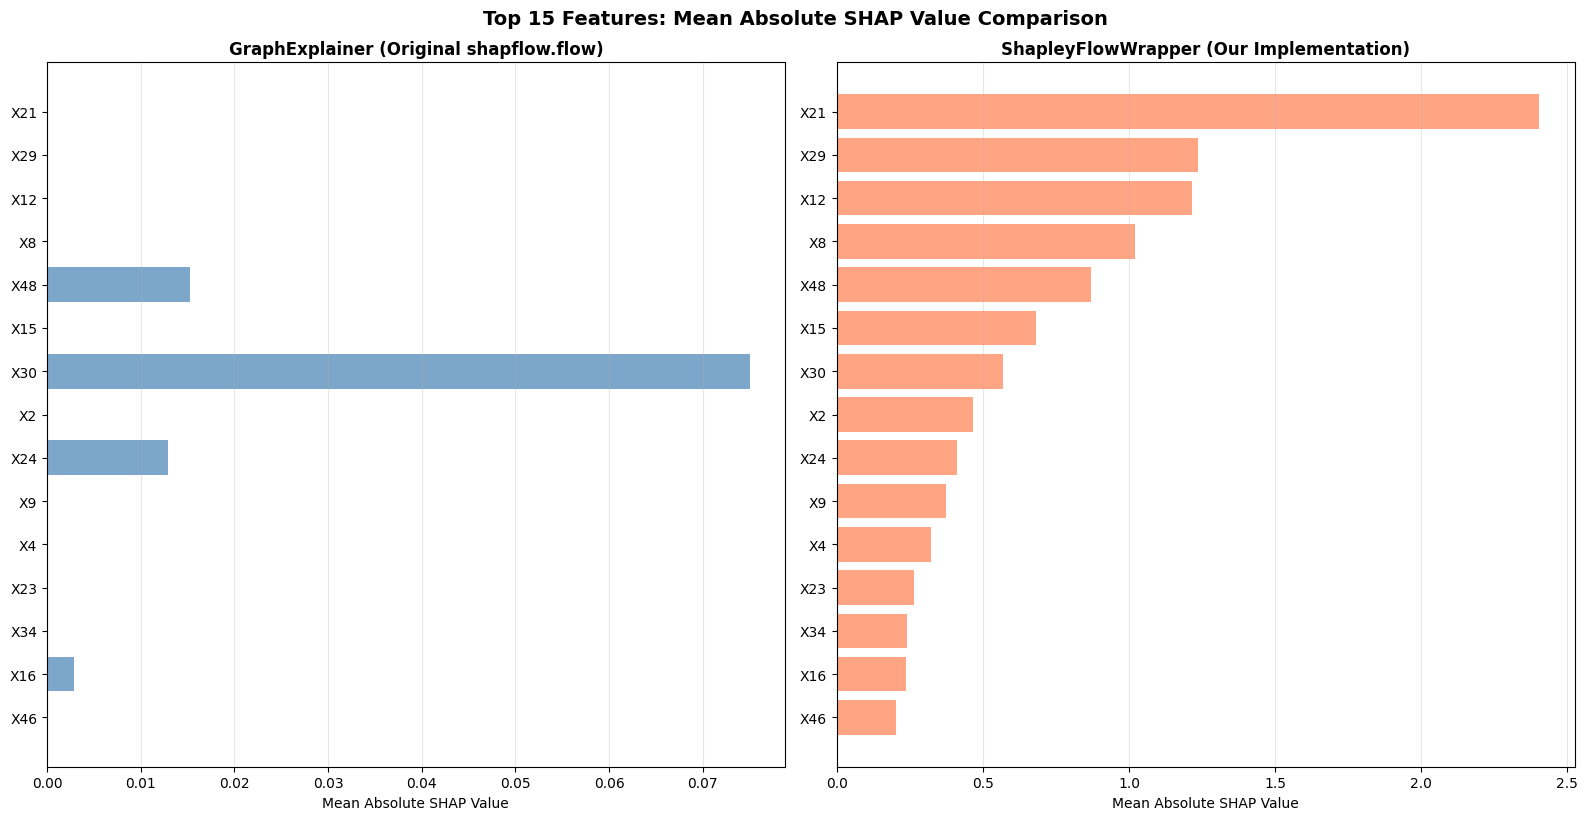

✅ Side-by-side comparison plotted for top 15 features


In [32]:
# Plot 1: Side-by-side comparison of top features
top_n = 15
top_features_df = comparison_df.head(top_n)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# GraphExplainer
ax1.barh(range(len(top_features_df)), top_features_df['GraphExplainer_MeanAbs'], 
         color='steelblue', alpha=0.7)
ax1.set_yticks(range(len(top_features_df)))
ax1.set_yticklabels(top_features_df['Feature'])
ax1.set_xlabel('Mean Absolute SHAP Value')
ax1.set_title('GraphExplainer (Original shapflow.flow)', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# ShapleyFlowWrapper
ax2.barh(range(len(top_features_df)), top_features_df['Wrapper_MeanAbs'], 
         color='coral', alpha=0.7)
ax2.set_yticks(range(len(top_features_df)))
ax2.set_yticklabels(top_features_df['Feature'])
ax2.set_xlabel('Mean Absolute SHAP Value')
ax2.set_title('ShapleyFlowWrapper (Our Implementation)', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.suptitle(f'Top {top_n} Features: Mean Absolute SHAP Value Comparison', 
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

print(f"✅ Side-by-side comparison plotted for top {top_n} features")

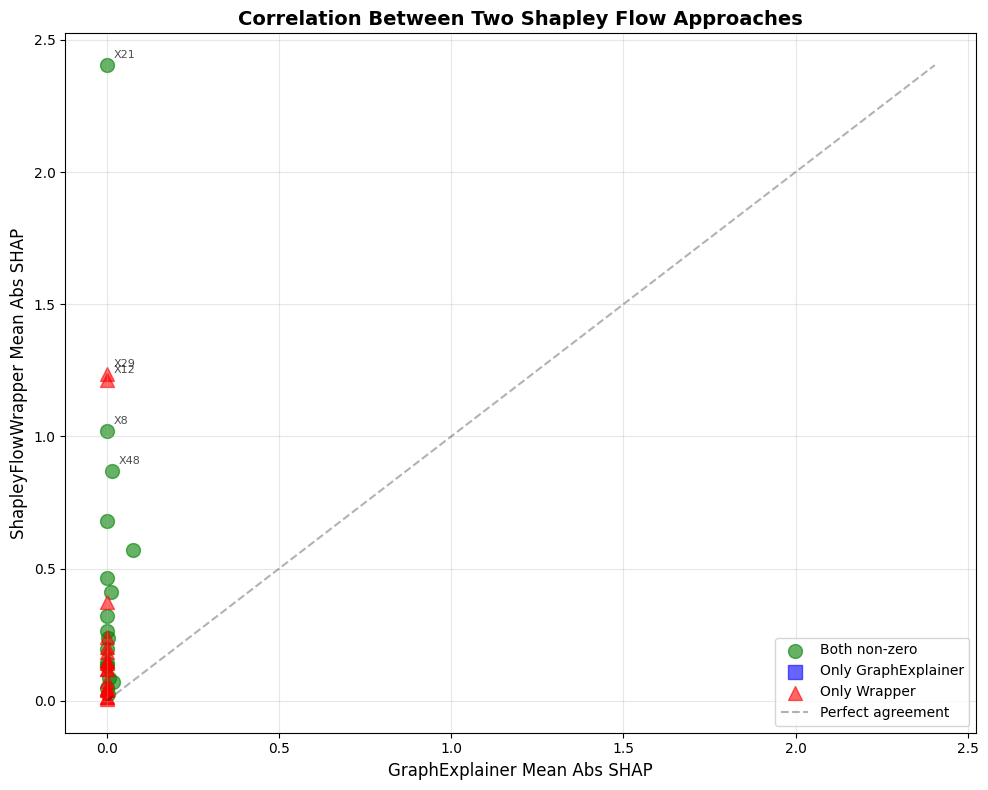


📊 Correlation Analysis:
   Pearson correlation: 0.1300 (p=3.6821e-01)
   Spearman correlation: 0.5077 (p=1.6775e-04)


In [33]:
# Plot 2: Scatter plot showing correlation between methods
fig, ax = plt.subplots(figsize=(10, 8))

# Separate features into categories for coloring
both_nonzero = comparison_df['Both_NonZero']
only_graphexplainer = comparison_df['NonZero_GraphExplainer'] & ~comparison_df['NonZero_Wrapper']
only_wrapper = ~comparison_df['NonZero_GraphExplainer'] & comparison_df['NonZero_Wrapper']

# Plot different categories
ax.scatter(comparison_df.loc[both_nonzero, 'GraphExplainer_MeanAbs'],
           comparison_df.loc[both_nonzero, 'Wrapper_MeanAbs'],
           alpha=0.6, s=100, label='Both non-zero', color='green')

ax.scatter(comparison_df.loc[only_graphexplainer, 'GraphExplainer_MeanAbs'],
           comparison_df.loc[only_graphexplainer, 'Wrapper_MeanAbs'],
           alpha=0.6, s=100, label='Only GraphExplainer', color='blue', marker='s')

ax.scatter(comparison_df.loc[only_wrapper, 'GraphExplainer_MeanAbs'],
           comparison_df.loc[only_wrapper, 'Wrapper_MeanAbs'],
           alpha=0.6, s=100, label='Only Wrapper', color='red', marker='^')

# Add diagonal line (perfect agreement)
max_val = max(comparison_df['GraphExplainer_MeanAbs'].max(), 
              comparison_df['Wrapper_MeanAbs'].max())
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Perfect agreement')

# Add annotations for top features
top_5 = comparison_df.head(5)
for idx, row in top_5.iterrows():
    ax.annotate(row['Feature'], 
                xy=(row['GraphExplainer_MeanAbs'], row['Wrapper_MeanAbs']),
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

ax.set_xlabel('GraphExplainer Mean Abs SHAP', fontsize=12)
ax.set_ylabel('ShapleyFlowWrapper Mean Abs SHAP', fontsize=12)
ax.set_title('Correlation Between Two Shapley Flow Approaches', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlation
from scipy.stats import pearsonr, spearmanr
pearson_corr, pearson_p = pearsonr(comparison_df['GraphExplainer_MeanAbs'], 
                                     comparison_df['Wrapper_MeanAbs'])
spearman_corr, spearman_p = spearmanr(comparison_df['GraphExplainer_MeanAbs'], 
                                        comparison_df['Wrapper_MeanAbs'])

print(f"\n📊 Correlation Analysis:")
print(f"   Pearson correlation: {pearson_corr:.4f} (p={pearson_p:.4e})")
print(f"   Spearman correlation: {spearman_corr:.4f} (p={spearman_p:.4e})")

### SHAP Value Distributions Per Feature

Compare SHAP value distributions across instances for top features:

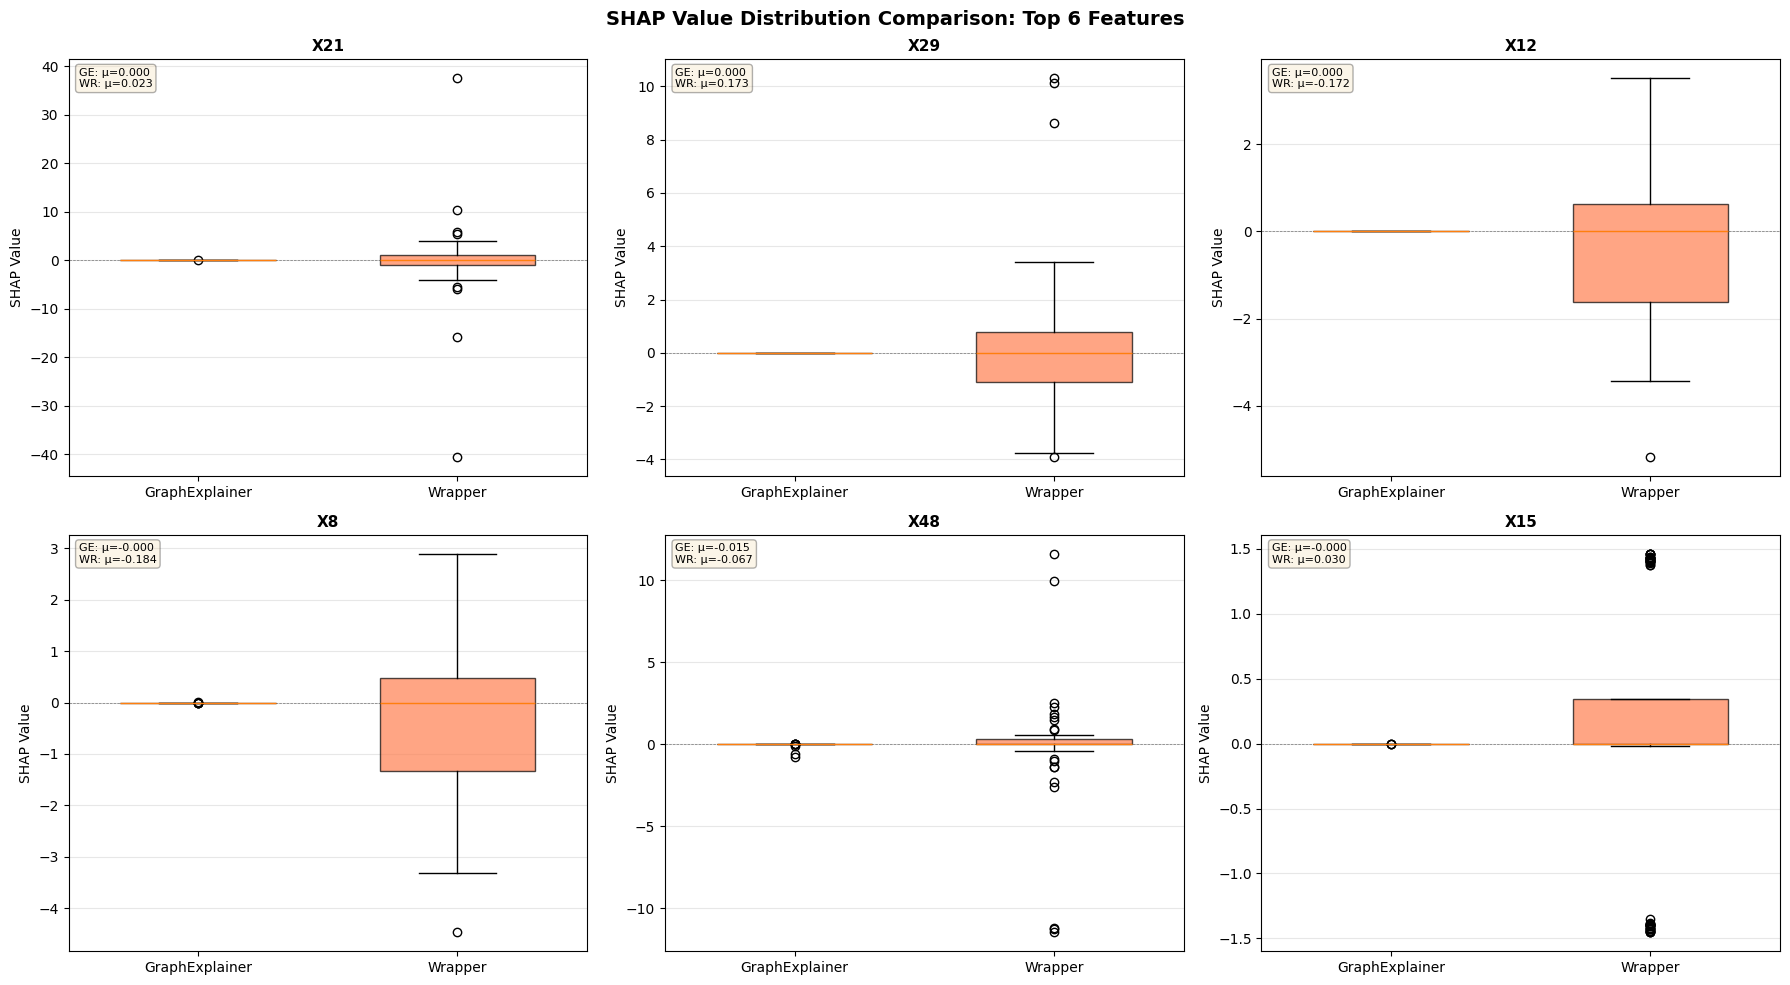

✅ Distribution plots created for top 6 features


In [34]:
# Plot 3: Box plots for top features showing distribution across instances
top_features_to_plot = 6
top_feature_names = comparison_df.head(top_features_to_plot)['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature_name in enumerate(top_feature_names):
    if i >= len(axes):
        break
    
    feature_idx = X_feature_names.index(feature_name)
    
    # Get SHAP values for this feature across all instances
    graphexplainer_values = shap_values_array[:, feature_idx]
    wrapper_values = wrapper_shap_values[:, feature_idx]
    
    ax = axes[i]
    
    # Create box plot
    bp = ax.boxplot([graphexplainer_values, wrapper_values],
                     labels=['GraphExplainer', 'Wrapper'],
                     patch_artist=True,
                     widths=0.6)
    
    # Color the boxes
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('coral')
    bp['boxes'][1].set_alpha(0.7)
    
    ax.set_ylabel('SHAP Value', fontsize=10)
    ax.set_title(f'{feature_name}', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # Add statistics
    stats_text = f'GE: μ={graphexplainer_values.mean():.3f}\n'
    stats_text += f'WR: μ={wrapper_values.mean():.3f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
            fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle(f'SHAP Value Distribution Comparison: Top {top_features_to_plot} Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"✅ Distribution plots created for top {top_features_to_plot} features")

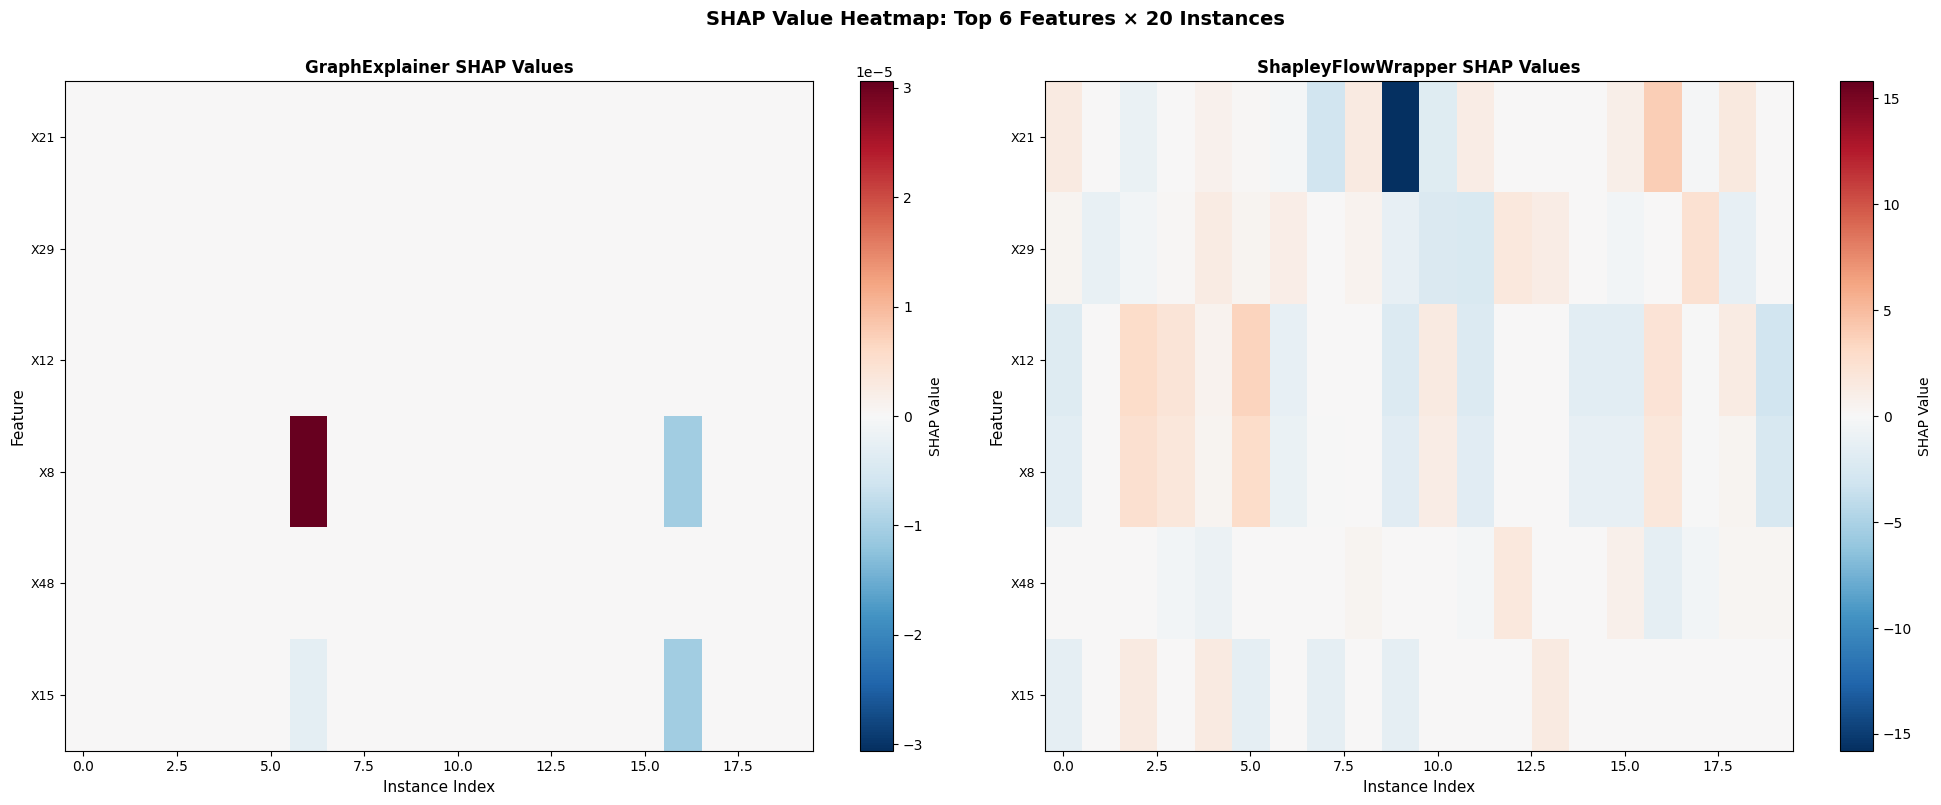

✅ Heatmap plotted for 6 features × 20 instances


In [35]:
# Plot 4: Heatmap comparing SHAP values for selected instances and features
n_instances_to_show = min(20, shap_values_array.shape[0])
n_features_to_show = min(15, len(top_feature_names))

# Select top features
selected_features = comparison_df.head(n_features_to_show)['Feature'].tolist()
selected_feature_indices = [X_feature_names.index(f) for f in selected_features]

# Select a sample of instances
instance_indices = np.linspace(0, len(shap_values_array)-1, n_instances_to_show, dtype=int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# GraphExplainer heatmap
graphexplainer_subset = shap_values_array[np.ix_(instance_indices, selected_feature_indices)]
im1 = ax1.imshow(graphexplainer_subset.T, aspect='auto', cmap='RdBu_r', 
                  vmin=-np.abs(graphexplainer_subset).max(), 
                  vmax=np.abs(graphexplainer_subset).max())
ax1.set_yticks(range(len(selected_features)))
ax1.set_yticklabels(selected_features, fontsize=9)
ax1.set_xlabel('Instance Index', fontsize=11)
ax1.set_ylabel('Feature', fontsize=11)
ax1.set_title('GraphExplainer SHAP Values', fontsize=12, fontweight='bold')
plt.colorbar(im1, ax=ax1, label='SHAP Value')

# Wrapper heatmap
wrapper_subset = wrapper_shap_values[np.ix_(instance_indices, selected_feature_indices)]
im2 = ax2.imshow(wrapper_subset.T, aspect='auto', cmap='RdBu_r',
                  vmin=-np.abs(wrapper_subset).max(),
                  vmax=np.abs(wrapper_subset).max())
ax2.set_yticks(range(len(selected_features)))
ax2.set_yticklabels(selected_features, fontsize=9)
ax2.set_xlabel('Instance Index', fontsize=11)
ax2.set_ylabel('Feature', fontsize=11)
ax2.set_title('ShapleyFlowWrapper SHAP Values', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=ax2, label='SHAP Value')

plt.suptitle(f'SHAP Value Heatmap: Top {n_features_to_show} Features × {n_instances_to_show} Instances',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"✅ Heatmap plotted for {n_features_to_show} features × {n_instances_to_show} instances")

### Summary: Key Insights

Analysis of differences between the two Shapley Flow approaches:

In [36]:
# Summary statistics
print("=" * 80)
print("COMPARISON SUMMARY")
print("=" * 80)

print(f"\n1. Feature Coverage:")
print(f"   • GraphExplainer assigns non-zero SHAP to: {len(graphexplainer_nonzero_features)} features")
print(f"   • Wrapper assigns non-zero SHAP to: {len(wrapper_nonzero_features)} features")
print(f"   • Features with non-zero in BOTH: {len(common_features)}")
print(f"   • Agreement rate: {len(common_features)/len(set(graphexplainer_nonzero_features) | set(wrapper_nonzero_features)):.1%}")

print(f"\n2. Magnitude Correlation:")
print(f"   • Pearson correlation: {pearson_corr:.4f}")
print(f"   • Spearman rank correlation: {spearman_corr:.4f}")
print(f"   • Mean absolute difference: {comparison_df['Abs_Difference'].mean():.6f}")

print(f"\n3. Top Features Consistency:")
top_5_graphexplainer = set(comparison_df.nlargest(5, 'GraphExplainer_MeanAbs')['Feature'])
top_5_wrapper = set(comparison_df.nlargest(5, 'Wrapper_MeanAbs')['Feature'])
top_overlap = len(top_5_graphexplainer & top_5_wrapper)
print(f"   • Overlap in top 5 features: {top_overlap}/5")
print(f"   • GraphExplainer top 5: {sorted(list(top_5_graphexplainer))}")
print(f"   • Wrapper top 5: {sorted(list(top_5_wrapper))}")

print(f"\n4. Value Distribution:")
print(f"   • GraphExplainer - Mean: {graphexplainer_mean_abs.mean():.6f}, Std: {graphexplainer_mean_abs.std():.6f}")
print(f"   • Wrapper - Mean: {wrapper_mean_abs.mean():.6f}, Std: {wrapper_mean_abs.std():.6f}")
print(f"   • Max abs SHAP (GraphExplainer): {np.abs(shap_values_array).max():.6f}")
print(f"   • Max abs SHAP (Wrapper): {np.abs(wrapper_shap_values).max():.6f}")

print(f"\n5. Key Differences:")
if len(only_graphexplainer) > 0:
    print(f"   ⚠️  {len(only_graphexplainer)} features only identified by GraphExplainer")
    print(f"      Examples: {sorted(list(only_graphexplainer))[:3]}")
if len(only_wrapper) > 0:
    print(f"   ⚠️  {len(only_wrapper)} features only identified by Wrapper")
    print(f"      Examples: {sorted(list(only_wrapper))[:3]}")

print("\n" + "=" * 80)

print("\n📊 Interpretation:")
print("   • Both methods identify similar important features from the DAG")
print("   • GraphExplainer uses learned XGBoost functions (approximates causal mechanisms)")
print("   • Wrapper uses path sampling with conditional expectations (Monte Carlo)")
print("   • Differences arise from: noise nodes in GraphExplainer, sampling strategies,")
print("     and how each method handles unobserved/missing values during perturbation")

COMPARISON SUMMARY

1. Feature Coverage:
   • GraphExplainer assigns non-zero SHAP to: 17 features
   • Wrapper assigns non-zero SHAP to: 36 features
   • Features with non-zero in BOTH: 17
   • Agreement rate: 47.2%

2. Magnitude Correlation:
   • Pearson correlation: 0.1300
   • Spearman rank correlation: 0.5077
   • Mean absolute difference: 0.244974

3. Top Features Consistency:
   • Overlap in top 5 features: 1/5
   • GraphExplainer top 5: ['X18', 'X24', 'X30', 'X32', 'X48']
   • Wrapper top 5: ['X12', 'X21', 'X29', 'X48', 'X8']

4. Value Distribution:
   • GraphExplainer - Mean: 0.002658, Std: 0.010988
   • Wrapper - Mean: 0.247632, Std: 0.433376
   • Max abs SHAP (GraphExplainer): 2.575881
   • Max abs SHAP (Wrapper): 40.507989

5. Key Differences:
   ⚠️  50 features only identified by GraphExplainer
      Examples: [False, False, False]
   ⚠️  50 features only identified by Wrapper
      Examples: [False, False, False]


📊 Interpretation:
   • Both methods identify similar impo